# 计算态演化

## 薛定谔演化

### 格式1：使用函数 `evolve_and_measure`


In [1]:
import quante as qt

qt.basicfun.clear_numba_cache()

In [1]:
import quante as qt
import numpy as np
op = qt.generate.operas.spin

L = 14
basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)

# Model
J, γ = 1., 0.0
builder = op.builder()
for l in range(L-1):
    builder += '+-', [l+1, l], 1/2 * (J + γ),
    builder += '+-', [l, l+1], 1/2 * (J - γ),
ham = builder.build()
hammat = ham.to_matrix(basis=basis, pauli=False, sparse=True)

tlist = np.linspace(0, 20, 100)
init_state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
obsoper = [op.z(L//2).to_matrix(basis, pauli=False, sparse=True)]

ee = qt.linalg.make_evolve_engine(hammat, init_state, tlist, herm=True)
ee.run(measure=obsoper).T

100%|##########| 100/100 [00:00<00:00, 270.59it/s]


array([[ 0.5       ,  0.47980118,  0.42164713,  0.33253709,  0.22308953,  0.10612674, -0.00501955, -0.09824517, -0.16421254, -0.19748206, -0.19708615, -0.16647764, -0.11287372, -0.04610224,  0.02287411,  0.0835382 ,  0.12727603,  0.1485071 ,  0.14533623,  0.11964845,  0.07665205,  0.02395539, -0.02967124, -0.07565575, -0.10690087, -0.11879135, -0.10979136, -0.08155793, -0.03857149,  0.01264281,  0.06456951,  0.10986219,  0.14242697,  0.15826699,  0.15596783,  0.13676361,  0.10419134,  0.06340572,  0.02027783, -0.01956871, -0.05162537, -0.07313259, -0.08338471, -0.08366784, -0.07685505, -0.06673988, -0.05723193, -0.05155995, -0.05162415, -0.05761304, -0.0679533 , -0.07960367, -0.08864369, -0.09105615, -0.0835671 , -0.06439391, -0.03376474,  0.00589232,  0.05013852,  0.09307819,  0.12820078,  0.14938479,  0.15190527,  0.1332805 ,  0.09381296,  0.03672419, -0.03215621, -0.10511715, -0.17361179, -0.22947231, -0.26611251, -0.27953324, -0.26897027, -0.23707489, -0.18958582, -0.1345278 , -0.0

array([ 0.5       ,  0.47980118,  0.42164713,  0.33253709,  0.22308953,  0.10612674, -0.00501955, -0.09824517, -0.16421254, -0.19748206, -0.19708615, -0.16647764, -0.11287372, -0.04610224,  0.02287411,  0.0835382 ,  0.12727603,  0.1485071 ,  0.14533623,  0.11964845,  0.07665205,  0.02395539, -0.02967124, -0.07565575, -0.10690087, -0.11879135, -0.10979136, -0.08155793, -0.03857149,  0.01264281,  0.06456951,  0.10986219,  0.14242697,  0.15826699,  0.15596783,  0.13676361,  0.10419134,  0.06340572,  0.02027783, -0.01956871, -0.05162537, -0.07313259, -0.08338471, -0.08366784, -0.07685505, -0.06673988, -0.05723193, -0.05155995, -0.05162415, -0.05761304, -0.0679533 , -0.07960367, -0.08864369, -0.09105615, -0.0835671 , -0.06439391, -0.03376474,  0.00589232,  0.05013852,  0.09307819,  0.12820078,  0.14938479,  0.15190527,  0.1332805 ,  0.09381296,  0.03672419, -0.03215621, -0.10511715, -0.17361179, -0.22947231, -0.26611251, -0.27953324, -0.26897027, -0.23707489, -0.18958582, -0.1345278 , -0.08

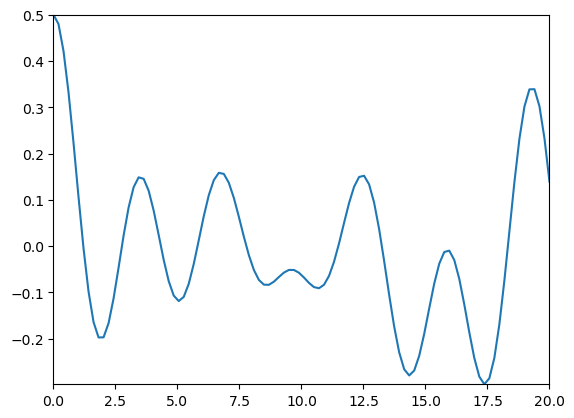

In [2]:
ee = qt.linalg.make_evolve_engine(hammat, init_state, tlist, herm=True)
ee.plot(measure=obsoper)

## 主方程演化

PHYSICAL REVIEW LETTERS 127, 070402 (2021)

$$
    \mathcal{L}(\rho) = -i [H, \rho] + \sum_{l} L_l \rho L_l^{\dagger} - \frac{1}{2} \sum_{l} (L_l^{\dagger} L_l \rho + \rho L_l^{\dagger} L_l)
$$

In [3]:
import quante as qt
import numpy as np

op = qt.generate.operas

L = 10
J = 1.
gamma_R = 1.0
gamma_L = 0.5

ham = op.builder()
for i in range(L-1):
    ham += "+-", [i+1, i], -J
    ham += "+-", [i, i+1], -J
ham = ham.build()

jump_R = [np.sqrt(gamma_R) * op.pm(i+1,i) for i in range(L-1)]
jump_L = [np.sqrt(gamma_L) * op.pm(i,i+1) for i in range(L-1)]
jump_ops = jump_R + jump_L
liou = op.Lindbladian(L, ham, jump_ops)

basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)
liou_dyn = liou.to_dynamics(basis=basis, pauli=False, sparse=True)

state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
rhoinit = np.outer(state, state)

obsoper = [op.z(i).to_matrix(basis, pauli=False, sparse=True) for i in range(L)]
tlist = np.linspace(0, 5, 50)

ee = qt.linalg.ExpmMulEvolveEngine(liou_dyn, rhoinit, tlist)
ee.run(measure=obsoper);

100%|##########| 50/50 [00:00<00:00, 51.92it/s]


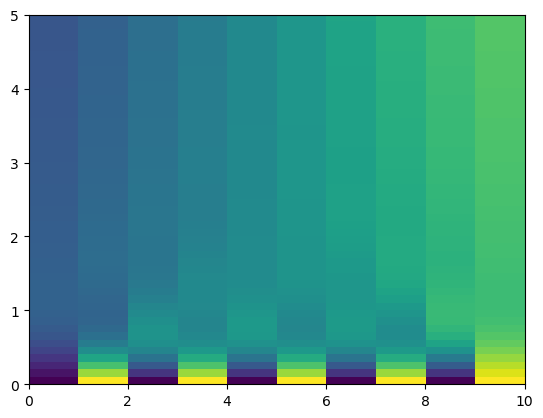

In [4]:
liou_mat = liou.to_matrix(basis=basis, pauli=False, sparse=True)

state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
dim = basis.Ns
rhoinit = np.outer(state, state)

obsoper = [op.z(i).to_matrix(basis, pauli=False, sparse=True) for i in range(L)]
measure = lambda t, rho: np.array([qt.measure.expect(o, rho.reshape(dim,dim), isdm=True) for o in obsoper])
tlist = np.linspace(0, 5, 50)

ee = qt.linalg.make_evolve_engine(liou_mat, rhoinit, tlist, matrix_role='generator')
ee.plot(measure=measure);

稳态

In [5]:
res = qt.linalg.steady_state(liou_dyn, 'svd')
measure(0, res)

array([-0.25866936, -0.21675229, -0.1612402 , -0.09951408, -0.03366661,  0.03366661,  0.09951408,  0.1612402 ,  0.21675229,  0.25866936])

# Symmetry of Lindbladian

In [4]:
import quante as qt
import numpy as np

op = qt.generate.operas

L = 31
J = 1.
gamma_R = 1.0
gamma_L = 0.5

ham = op.builder()
for i in range(L-1):
    ham += "+-", [i+1, i], -J
    ham += "+-", [i, i+1], -J
ham = ham.build()

jump_R = [np.sqrt(gamma_R) * op.pm(i+1,i) for i in range(L-1)]
jump_L = [np.sqrt(gamma_L) * op.pm(i,i+1) for i in range(L-1)]
jump_ops = jump_R + jump_L
liou = op.super_oper.Lindbladian(L, ham, jump_ops)

basis = qt.generate.basis.spin_super_basis(L=L, Nup2=1)
liou_mat = liou.to_matrix(basis=basis, pauli=False, sparse=False)

state = qt.generate.state.product_state(['up']+['dn']*(L-1), Nup=1)
# print(state.shape)
# rhoinit = basis.project(np.outer(state, state).reshape(-1))
basis.projection_matrix()
# print(rhoinit.dtype)
# print(rhoinit.shape)

# basis0 = qt.generate.basis.spin_basis(L=L, Nup=1)
# particle_number_mat = []
# for i in range(L):
#     n_i = op.n(i).to_matrix(basis=basis0, pauli=False, sparse=False).reshape(-1)
#     n_i_proj = basis.project(n_i, Nup2=1).reshape(-1)
#     particle_number_mat.append(n_i_proj)
# measure = lambda t, rho: [n @ rho.reshape(-1) for n in particle_number_mat]

# res = qt.linalg.evolve_and_measure(
#     liou_mat, rhoinit, [10, 20, 30, 40, 50], 
#     measure=measure, matrix_role='generator'
# )


# import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(6, 4))
# ax = fig.add_subplot(1, 1, 1)
# ax.plot(res.T, "o-");

ValueError: array is too big; `arr.size * arr.dtype.itemsize` is larger than the maximum possible size.

## 不同方法的 benchmark

In [10]:
import quante as qt
L = 12
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, pauli=False, sparse=True)
state = qt.generate.state.random(basis.Ns, seed=42)
qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, herm=True);

In [11]:
import quante as qt
import numpy as np
import scipy.sparse as sp
import time

## 初始化态和哈密顿量

In [12]:
# 拿到矩阵
L = 12
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, pauli=False, sparse=True)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

## 比较不同方法的计算结果

### 用本征分解的方法计算

In [13]:
res = qt.linalg.eigh(mat)
times = np.linspace(0,10,100)
qt.linalg.get_time_evolution_states_ED(state,*res,times, device_name='cpu')

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 用 scipy 的 expm_multiply

In [14]:
res = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 使用 quante 的 expm_multiply

In [15]:
res = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

针对实矩阵的优化

In [16]:
res = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

## 比较运行速度

In [17]:
runlarge = False

生成一个较大的矩阵

In [18]:
if runlarge:
    # 拿到矩阵
    L = 18
    ham = qt.generate.operas.spin.heisenberg_operator(L)
    basis = qt.generate.basis.spin_basis(L)
    mat = ham.to_matrix(basis, sparse=True)
    print("space dimension:", basis.Ns)

    # 拿到态
    state = qt.generate.state.random(basis.Ns, seed=42)

比较四种方法运行所需要的时间

In [19]:
if runlarge:
    # 方法1:
    import scipy.sparse as sp

    t = time.time()
    res1 = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
    print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

    t = time.time()
    res2 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, herm=True)
    print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

    t = time.time()
    res3 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    t = time.time()
    res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    print("norm difference between first two:", np.allclose(res1, res2))
    print("norm difference between last two:", np.allclose(res2, res3))
    print("norm difference between last two:", np.allclose(res3, res4))

one result:
```text
time scipy.expm_multiple: 26.11s
time quante.expm_multiple with cpu parallel: 16.98s
time quante.expm_multiple with gpu cuda: 2.52s
time quante.expm_multiple with gpu cuda: 1.28s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True
```

建一个更大的矩阵

In [20]:
if runlarge:
    L = 22
    ham = qt.generate.operas.spin.heisenberg_operator(L)
    basis = qt.generate.basis.spin_basis(L)
    mat = ham.to_matrix(basis, sparse=True)
    print("space dimension:", basis.Ns)

    # 拿到态
    state = qt.generate.state.random(basis.Ns, seed=42)

演化 1s 需要的时间

In [21]:
if runlarge:
    # 方法1:
    t = time.time()
    res1 = sp.linalg.expm_multiply((-1j*mat), state)
    print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

    t = time.time()
    res2 = qt.linalg.expm_multiply((-1j*mat), state, herm=True)
    print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

    t = time.time()
    res3 = qt.linalg.expm_multiply((-1j*mat), state, device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    t = time.time()
    res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    print("norm difference between first two:", np.allclose(res1, res2))
    print("norm difference between last two:", np.allclose(res1, res3))
    print("norm difference between last two:", np.allclose(res1, res4))

one result:
```text
time scipy.expm_multiple: 16.74s
time quante.expm_multiple with cpu parallel: 9.79s
time quante.expm_multiple with gpu cuda: 2.21s
time quante.expm_multiple with gpu cuda: 1.27s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True
```

所能运行的最大尺寸

In [22]:
if runlarge:
    # 拿到矩阵
    L = 26
    ham = qt.generate.operas.spin.heisenberg_operator(L)
    ham = ham.expandxy()
    basis = qt.generate.basis.spin_basis(L)
    t = time.time()
    mat = ham.to_matrix(basis, sparse=True)
    print(f"time to generate matrix: {time.time()-t:.2f}s")

    print("space dimension:", basis.Ns)

    # 拿到态
    state = qt.generate.state.random(basis.Ns, seed=42)

    t = time.time()
    res3 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

```text
time to generate matrix: 41.90s
space dimension: 67108864
time quante.expm_multiple with gpu cuda: 22.14s
```

In [23]:
if runlarge:
    print(f"哈密顿量内存占用：",end="")
    qt.basicfun.print_memory_usage(mat)
    print(f"演化态内存占用：",end="");
    qt.basicfun.print_memory_usage(res3)

```text
哈密顿量内存占用：10.38 GB
演化态内存占用：1.00 GB
```